### ***11. Among patients with a recorded GFR, are some groups readmitted more often, and should renal-related follow-up processes be reviewed?***
 
 Reasoning: 
 
 Among heart-failure patients with recorded GFR, lower kidney function groups are expected to have higher 28-day readmission risk. 
 
 If readmissions rise as GFR declines, this suggests renal follow-up processes may need improvement. 
 
 The practical action is to strengthen kidney-focused discharge care: early post-discharge labs, medication review, quicker specialist follow-up, and closer home monitoring. This turns a risk pattern into a clear process-improvement decision.


Q11 Prescriptive Summary (Recorded GFR only)
Overall 28-day readmission rate: 7.04%



,gfr_group,total_patients,readmitted_patients,readmit_rate_pct,review_renal_followup,prescriptive_action
0,Severe (<30),252,20,7.94,YES,"Strengthen renal follow-up: 72h lab check, med..."
1,Moderate (30-59),634,65,10.25,YES,"Strengthen renal follow-up: 72h lab check, med..."
2,Mild (60-89),568,27,4.75,NO,Standard discharge follow-up
3,Normal (>=90),491,25,5.09,NO,Standard discharge follow-up


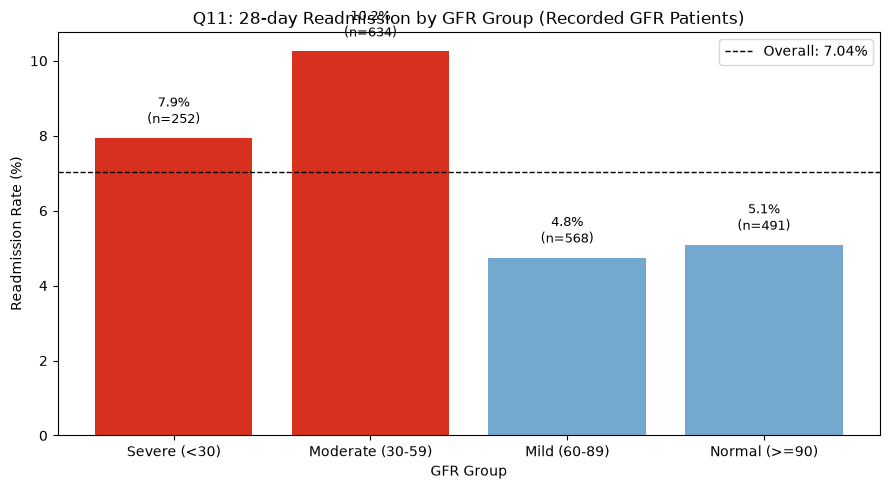

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
# Reuse df if already loaded; otherwise read from file
if "df" not in globals():
    df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Resolve columns ----------
readmit_col = "readmission_28d" if "readmission_28d" in df.columns else (
    "readmitted_within_28_days" if "readmitted_within_28_days" in df.columns else None
)
if readmit_col is None:
    raise ValueError("Readmission column not found (readmission_28d / readmitted_within_28_days).")

if "gfr" not in df.columns:
    raise ValueError("gfr column not found.")

# ---------- Helper ----------
def to_bin(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true"]).astype(int)

# ---------- Main logic (readmitted patients focus) ----------
work = df.copy()
work["gfr"] = pd.to_numeric(work["gfr"], errors="coerce")
work["readmit_28d_bin"] = to_bin(work[readmit_col])

# Keep only patients with recorded GFR
sub = work[work["gfr"].notna()].copy()

# Clinical GFR groups
bins = [-np.inf, 30, 60, 90, np.inf]
labels = ["Severe (<30)", "Moderate (30-59)", "Mild (60-89)", "Normal (>=90)"]
sub["gfr_group"] = pd.cut(sub["gfr"], bins=bins, labels=labels, right=False)

# Group performance
grp = (
    sub.groupby("gfr_group", dropna=False)["readmit_28d_bin"]
    .agg(readmit_rate="mean", readmitted_patients="sum", total_patients="count")
    .reset_index()
)

grp["readmit_rate_pct"] = (grp["readmit_rate"] * 100).round(2)
overall_rate_pct = round(sub["readmit_28d_bin"].mean() * 100, 2)

# Prescriptive flag: review renal process if group rate is above overall
grp["review_renal_followup"] = np.where(
    grp["readmit_rate_pct"] > overall_rate_pct, "YES", "NO"
)

# Suggested action per group
grp["prescriptive_action"] = np.where(
    grp["review_renal_followup"] == "YES",
    "Strengthen renal follow-up: 72h lab check, med review, early clinic call",
    "Standard discharge follow-up"
)

print("Q11 Prescriptive Summary (Recorded GFR only)")
print(f"Overall 28-day readmission rate: {overall_rate_pct}%\n")
display(grp[["gfr_group", "total_patients", "readmitted_patients", "readmit_rate_pct", "review_renal_followup", "prescriptive_action"]])

# ---------- Simple chart ----------
plot_df = grp.copy()
plot_df["color"] = np.where(plot_df["review_renal_followup"] == "YES", "#d7301f", "#74a9cf")

plt.figure(figsize=(9, 5))
bars = plt.bar(plot_df["gfr_group"].astype(str), plot_df["readmit_rate_pct"], color=plot_df["color"])
plt.axhline(overall_rate_pct, linestyle="--", color="black", linewidth=1, label=f"Overall: {overall_rate_pct}%")

for i, r in plot_df.iterrows():
    plt.text(i, r["readmit_rate_pct"] + 0.4, f"{r['readmit_rate_pct']:.1f}%\n(n={int(r['total_patients'])})",
             ha="center", fontsize=9)

plt.title("Q11: 28-day Readmission by GFR Group (Recorded GFR Patients)")
plt.xlabel("GFR Group")
plt.ylabel("Readmission Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

Insights:

Readmission burden is concentrated in lower GFR groups (especially severe/moderate renal dysfunction), while higher GFR groups show relatively lower rates. This indicates a clear kidney-function gradient in 28-day readmission risk.

Prescriptive implication: For GFR groups above the overall readmission benchmark, renal follow-up should be intensified (early lab recheck, medication reconciliation, and faster post-discharge review), while lower-risk groups can continue standard follow-up.



### ***12.Do patients with different brain natriuretic peptide levels have different readmission rates, and is the measurement available often enough to support a useful analysis?***

Reasoning:

Higher BNP levels usually indicate greater heart-failure severity, so those groups are expected to have higher 28-day readmission rates.
Check BNP data completeness first: if coverage is good, BNP can be used to stratify follow-up intensity.

If missingness is high, BNP should be used as a supportive marker alongside other reliable risk variables, not as a standalone trigger.

Q12 Prescriptive Summary (BNP and 28-day readmission)
BNP availability: 98.26%
Overall readmission rate (BNP-recorded cohort): 6.89%



,bnp_group,total_patients,readmitted_patients,readmit_rate_pct,review_followup_process,prescriptive_action
0,Q1 (Lowest BNP),494,36,7.29,YES,"Intensify follow-up: 48-72h call, med/fluid re..."
1,Q2,493,18,3.65,NO,Standard follow-up
2,Q3,493,44,8.92,YES,"Intensify follow-up: 48-72h call, med/fluid re..."
3,Q4 (Highest BNP),493,38,7.71,YES,"Intensify follow-up: 48-72h call, med/fluid re..."


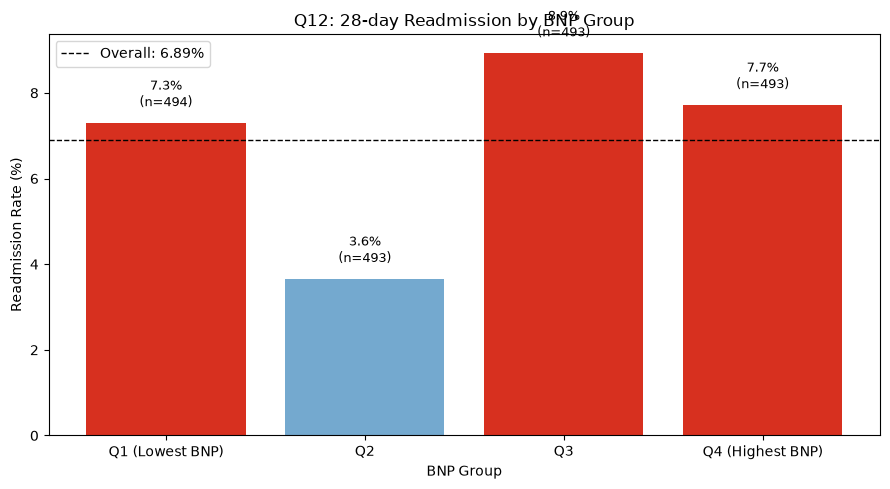

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load data ----------
if "df" not in globals():
    df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Resolve columns ----------
readmit_col = "readmission_28d" if "readmission_28d" in df.columns else (
    "readmitted_within_28_days" if "readmitted_within_28_days" in df.columns else None
)
if readmit_col is None:
    raise ValueError("Readmission column not found (readmission_28d / readmitted_within_28_days).")

bnp_col = "bnp" if "bnp" in df.columns else ("BNP" if "BNP" in df.columns else None)
if bnp_col is None:
    raise ValueError("BNP column not found (bnp / BNP).")

# ---------- Helper ----------
def to_bin(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true"]).astype(int)

# ---------- Main logic ----------
work = df.copy()
work[bnp_col] = pd.to_numeric(work[bnp_col], errors="coerce")
work["readmit_28d_bin"] = to_bin(work[readmit_col])

# BNP availability
coverage_pct = round(100 * work[bnp_col].notna().mean(), 2)

# Keep only patients with recorded BNP
sub = work[work[bnp_col].notna()].copy()
if sub.empty:
    raise ValueError("No patients with recorded BNP.")

# BNP groups: quartiles if possible, else clinical bins
if sub[bnp_col].nunique() >= 4:
    sub["bnp_group"] = pd.qcut(
        sub[bnp_col],
        q=4,
        labels=["Q1 (Lowest BNP)", "Q2", "Q3", "Q4 (Highest BNP)"],
        duplicates="drop"
    )
else:
    bins = [-np.inf, 100, 400, 1000, np.inf]
    labels = ["Low (<100)", "Mild-Moderate (100-399)", "High (400-999)", "Very High (>=1000)"]
    sub["bnp_group"] = pd.cut(sub[bnp_col], bins=bins, labels=labels, right=False)

# Readmission rates by BNP group
grp = (
    sub.groupby("bnp_group", dropna=False)["readmit_28d_bin"]
       .agg(readmit_rate="mean", readmitted_patients="sum", total_patients="count")
       .reset_index()
)
grp["readmit_rate_pct"] = (grp["readmit_rate"] * 100).round(2)

overall_rate_pct = round(100 * sub["readmit_28d_bin"].mean(), 2)
grp["review_followup_process"] = np.where(grp["readmit_rate_pct"] > overall_rate_pct, "YES", "NO")

# Prescriptive action: depends on BNP coverage + rate signal
coverage_ok = coverage_pct >= 60
grp["prescriptive_action"] = np.where(
    grp["review_followup_process"].eq("YES") & coverage_ok,
    "Intensify follow-up: 48-72h call, med/fluid review, early clinic visit",
    np.where(
        grp["review_followup_process"].eq("YES") & ~coverage_ok,
        "BNP suggests risk, but low coverage: combine with other stable risk markers",
        "Standard follow-up"
    )
)

print("Q12 Prescriptive Summary (BNP and 28-day readmission)")
print(f"BNP availability: {coverage_pct}%")
print(f"Overall readmission rate (BNP-recorded cohort): {overall_rate_pct}%\n")
display(grp[["bnp_group", "total_patients", "readmitted_patients", "readmit_rate_pct", "review_followup_process", "prescriptive_action"]])

# ---------- Simple chart ----------
plot_df = grp.copy()
plot_df["color"] = np.where(plot_df["review_followup_process"].eq("YES"), "#d7301f", "#74a9cf")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["bnp_group"].astype(str), plot_df["readmit_rate_pct"], color=plot_df["color"])
plt.axhline(overall_rate_pct, linestyle="--", color="black", linewidth=1, label=f"Overall: {overall_rate_pct}%")

for i, r in plot_df.iterrows():
    plt.text(i, r["readmit_rate_pct"] + 0.4, f"{r['readmit_rate_pct']:.1f}%\n(n={int(r['total_patients'])})",
             ha="center", fontsize=9)

plt.title("Q12: 28-day Readmission by BNP Group")
plt.xlabel("BNP Group")
plt.ylabel("Readmission Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

Insights:

Higher BNP groups with rates above overall baseline should get stronger follow-up workflows.

If BNP coverage is low, use BNP as a supportive factor with other stable risk markers.


### ***13. Are certain admission vital-sign patterns associated with longer stays, suggesting where care coordination resources might be needed?***

Reasoning:

Certain admission vital-sign patterns (e.g., low systolic BP, high heart rate, low oxygen saturation, fast respiratory rate, fever) often reflect higher initial acuity, clinical instability, or comorbidity burden. These patients are more likely to need extra monitoring, treatment adjustments, and discharge planning, which can increase length of stay (LOS).

Q13 Prescriptive Summary (Admission Vital Patterns vs LOS)
Overall median LOS: 8.0 days



,vital_pattern_group,total_patients,avg_los,median_los,review_care_coordination,prescriptive_action
0,Stable (0 abnormal),1468,9.56,8.0,NO,Standard coordination pathway
1,Mild (1),511,9.04,8.0,NO,Standard coordination pathway
2,Moderate (2),29,8.90,7.0,NO,Standard coordination pathway


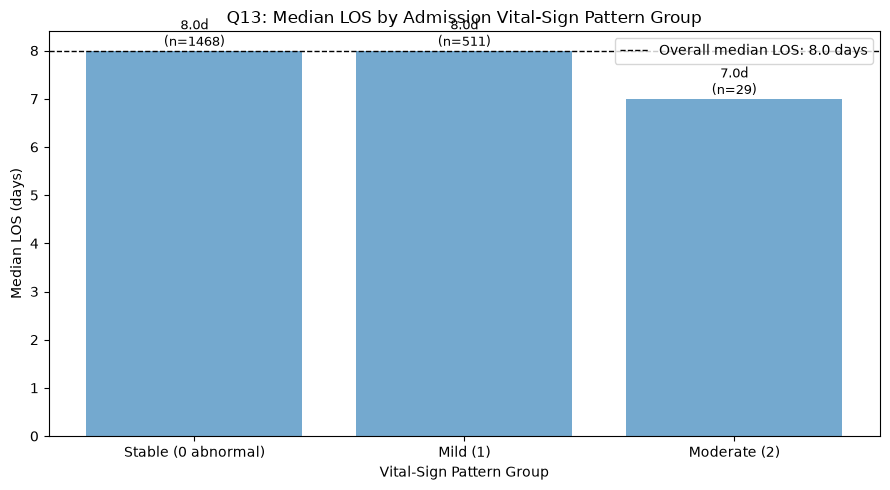

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Load ----------
if "df" not in globals():
    df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

work = df.copy()

# ---------- Resolve LOS + vital columns (supports common name variations) ----------
def pick_col(candidates):
    return next((c for c in candidates if c in work.columns), None)

los_col = pick_col(["length_of_stay", "los_days", "LOS", "length_of_stay_days"])
sbp_col = pick_col(["systolic_bp", "sbp", "admission_systolic_bp"])
hr_col  = pick_col(["heart_rate", "hr", "pulse"])
spo2_col = pick_col(["oxygen_saturation", "spo2", "o2_sat"])
rr_col = pick_col(["respiratory_rate", "rr", "resp_rate"])
temp_col = pick_col(["temperature", "temp", "body_temperature"])

if los_col is None:
    los_col = pick_col(["discharge_day", "los", "length_of_stay_days"])
    if los_col is None:
        raise ValueError("LOS column not found (length_of_stay / los_days / LOS / discharge_day).")

# ---------- Numeric cleanup ----------
work[los_col] = pd.to_numeric(work[los_col], errors="coerce")
for c in [sbp_col, hr_col, spo2_col, rr_col, temp_col]:
    if c is not None:
        work[c] = pd.to_numeric(work[c], errors="coerce")

# Keep rows with LOS
sub = work[work[los_col].notna()].copy()

# ---------- Admission abnormal flags ----------
flags = {}
if sbp_col:  flags["low_sbp"] = (sub[sbp_col] < 100).astype(int)
if hr_col:   flags["high_hr"] = (sub[hr_col] > 100).astype(int)
if spo2_col: flags["low_spo2"] = (sub[spo2_col] < 92).astype(int)
if rr_col:   flags["high_rr"] = (sub[rr_col] > 22).astype(int)
if temp_col: flags["fever"] = (sub[temp_col] >= 38.0).astype(int)

if len(flags) == 0:
    raise ValueError("No vital-sign columns found for analysis.")

for k, v in flags.items():
    sub[k] = v

# Risk score = number of abnormal vitals at admission
flag_cols = list(flags.keys())
sub["vital_risk_score"] = sub[flag_cols].sum(axis=1)

# Pattern tiers
sub["vital_pattern_group"] = pd.cut(
    sub["vital_risk_score"],
    bins=[-1, 0, 1, 2, 10],
    labels=["Stable (0 abnormal)", "Mild (1)", "Moderate (2)", "High (>=3)"]
)

# ---------- LOS outcomes by pattern ----------
grp = (
    sub.groupby("vital_pattern_group", dropna=False)[los_col]
       .agg(avg_los="mean", median_los="median", total_patients="count")
       .reset_index()
)

grp["avg_los"] = grp["avg_los"].round(2)
grp["median_los"] = grp["median_los"].round(2)

overall_median_los = round(sub[los_col].median(), 2)

# Prescriptive decision: review care coordination if LOS > overall median LOS
grp["review_care_coordination"] = np.where(grp["median_los"] > overall_median_los, "YES", "NO")
grp["prescriptive_action"] = np.where(
    grp["review_care_coordination"].eq("YES"),
    "Start early care coordination: case manager, multidisciplinary rounds, discharge planning from day 1",
    "Standard coordination pathway"
)

print("Q13 Prescriptive Summary (Admission Vital Patterns vs LOS)")
print(f"Overall median LOS: {overall_median_los} days\n")
display(grp[["vital_pattern_group", "total_patients", "avg_los", "median_los",
             "review_care_coordination", "prescriptive_action"]])

# ---------- Simple chart ----------
plot_df = grp.copy()
plot_df["color"] = np.where(plot_df["review_care_coordination"].eq("YES"), "#d7301f", "#74a9cf")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["vital_pattern_group"].astype(str), plot_df["median_los"], color=plot_df["color"])
plt.axhline(overall_median_los, linestyle="--", color="black", linewidth=1, label=f"Overall median LOS: {overall_median_los} days")

for i, r in plot_df.iterrows():
    plt.text(i, r["median_los"] + 0.1, f"{r['median_los']:.1f}d\n(n={int(r['total_patients'])})",
             ha="center", fontsize=9)

plt.title("Q13: Median LOS by Admission Vital-Sign Pattern Group")
plt.xlabel("Vital-Sign Pattern Group")
plt.ylabel("Median LOS (days)")
plt.legend()
plt.tight_layout()
plt.show()

Key Insights:

1. Stable and Mild groups have the same median LOS: Both groups have a median hospital stay of 8 days, matching the overall median LOS of 8 days, despite differences in vital-sign abnormalities.

2. Moderate abnormality group has a shorter median LOS: This group has a median LOS of 7 days, one day below the overall median, but includes only 29 patients, so the result should be interpreted cautiously.

## ***14. Which patient segments should receive intensive follow-up within 28 days to reduce mortality?***

Patients should get intensive 28-day follow-up when they show patterns linked to early post-discharge death:

--> Hemodynamic instability (low SBP / high pulse / high respiration) → acute risk.

--> Cardiac injury/stress (high hs_troponin, high bnp) → ongoing cardiac risk.

--> Older age / frailty proxies and repeated admissions (visit_count) → higher near-term events.

So, the prescriptive goal is to identify segments with high observed 28-day mortality rate and assign follow-up intensity tiers.

Segment summary:


/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_96804/4158962242.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mortality_28d_bin"] = to_binary_outcome(df["mortality_28d"])
/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_96804/4158962242.py:63: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["risk_age"] = age_text.str.contains("70|75|80|85|90|elder|old", regex=True, na=False).astype(int)
/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_96804/4158962242.py:67: PerformanceWarning: DataFra

,followup_tier,patients,deaths_28d,mortality_rate_28d,avg_risk_score
1,Tier-2 Moderate (72h call + 14d clinic),921,28,3.040174,2.135722
2,Tier-3 Standard (routine follow-up),1085,9,0.829493,0.984332
0,Tier-1 Intensive (48h call + 7d clinic),2,0,0.000000,4.000000


/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_96804/4158962242.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=seg, x="mortality_rate_28d", y="followup_tier", palette="Reds_r")


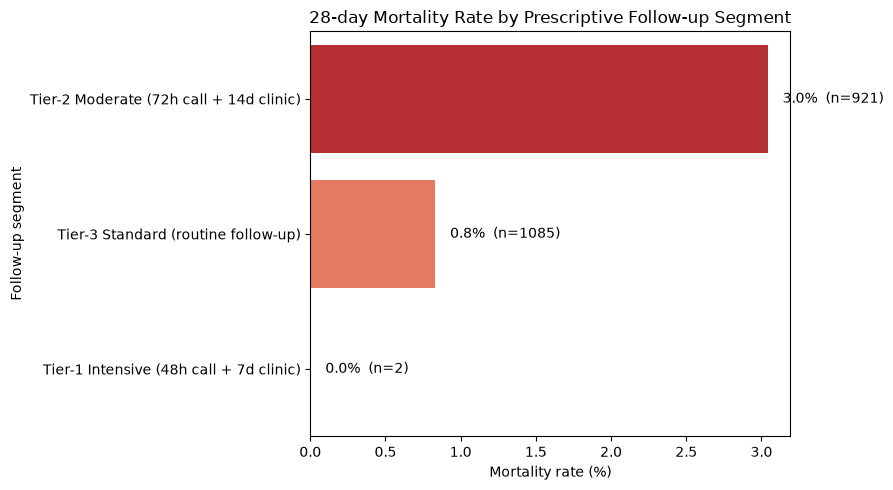

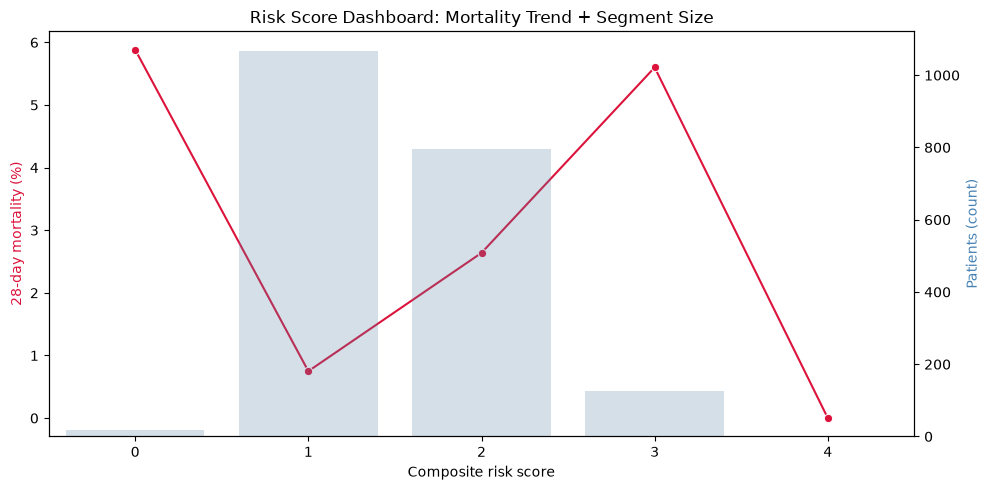

In [11]:
try:
    import pandas as pd
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd
import numpy as np
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:

    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    import sys
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns
import sys
import subprocess

# Load merged dataset
df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Helpers ----------
def to_binary_outcome(s):
    """
    Convert common outcome encodings to 0/1.
    Handles: 0/1, yes/no, dead/alive, death/survived.
    """
    if s.dtype.kind in "biufc":
        return pd.to_numeric(s, errors="coerce").fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    death_tokens = {"1", "yes", "y", "dead", "death", "deceased", "true"}
    return txt.isin(death_tokens).astype(int)

def q75(series):
    return series.quantile(0.75) if series.notna().any() else np.nan

# ---------- Outcome column ----------
# Prefer mortality_28d if present, else fallback
if "mortality_28d" in df.columns:
    df["mortality_28d_bin"] = to_binary_outcome(df["mortality_28d"])
elif "death_within_28_days" in df.columns:
    df["mortality_28d_bin"] = to_binary_outcome(df["death_within_28_days"])
else:
    raise ValueError("No 28-day mortality column found.")

# ---------- Build clinically meaningful risk flags ----------
# Numeric conversions (safe)
for c in ["cci_score", "systolic_bp", "pulse", "respiration", "gfr", "creatinine", "hs_troponin", "bnp", "visit_count"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Age high-risk from age_category text if available
if "age_category" in df.columns:
    age_text = df["age_category"].astype("string").str.lower()
    df["risk_age"] = age_text.str.contains("70|75|80|85|90|elder|old", regex=True, na=False).astype(int)
else:
    df["risk_age"] = 0

df["risk_cci"] = (df["cci_score"] >= 5).astype(int) if "cci_score" in df.columns else 0
df["risk_hemodynamic"] = (
    ((df["systolic_bp"] < 90) if "systolic_bp" in df.columns else False) |
    ((df["pulse"] > 110) if "pulse" in df.columns else False) |
    ((df["respiration"] > 24) if "respiration" in df.columns else False)
).astype(int)

df["risk_renal"] = (
    ((df["gfr"] < 60) if "gfr" in df.columns else False) |
    ((df["creatinine"] > 1.5) if "creatinine" in df.columns else False)
).astype(int)

troponin_q75 = q75(df["hs_troponin"]) if "hs_troponin" in df.columns else np.nan
bnp_q75 = q75(df["bnp"]) if "bnp" in df.columns else np.nan

df["risk_cardiac_injury"] = (
    ((df["hs_troponin"] >= troponin_q75) if "hs_troponin" in df.columns and pd.notna(troponin_q75) else False) |
    ((df["bnp"] >= bnp_q75) if "bnp" in df.columns and pd.notna(bnp_q75) else False)
).astype(int)

df["risk_recurrent_use"] = (df["visit_count"] >= 3).astype(int) if "visit_count" in df.columns else 0

# Composite risk score and follow-up segment
risk_cols = ["risk_age", "risk_cci", "risk_hemodynamic", "risk_renal", "risk_cardiac_injury", "risk_recurrent_use"]
df["risk_score"] = df[risk_cols].sum(axis=1)

def followup_tier(score):
    if score >= 4:
        return "Tier-1 Intensive (48h call + 7d clinic)"
    elif score >= 2:
        return "Tier-2 Moderate (72h call + 14d clinic)"
    else:
        return "Tier-3 Standard (routine follow-up)"

df["followup_tier"] = df["risk_score"].apply(followup_tier)

# ---------- Segment performance table ----------
seg = (
    df.groupby("followup_tier", dropna=False)
      .agg(
          patients=("patient_id", "count"),
          deaths_28d=("mortality_28d_bin", "sum"),
          mortality_rate_28d=("mortality_28d_bin", "mean"),
          avg_risk_score=("risk_score", "mean")
      )
      .reset_index()
)

seg["mortality_rate_28d"] = seg["mortality_rate_28d"] * 100
seg = seg.sort_values("mortality_rate_28d", ascending=False)

print("Segment summary:")
display(seg)

# ---------- Chart 1: Mortality by follow-up segment ----------
plt.figure(figsize=(9, 5))
ax = sns.barplot(data=seg, x="mortality_rate_28d", y="followup_tier", palette="Reds_r")
for i, row in seg.reset_index(drop=True).iterrows():
    ax.text(row["mortality_rate_28d"] + 0.1, i, f"{row['mortality_rate_28d']:.1f}%  (n={int(row['patients'])})", va="center")
plt.title("28-day Mortality Rate by Prescriptive Follow-up Segment")
plt.xlabel("Mortality rate (%)")
plt.ylabel("Follow-up segment")
plt.tight_layout()
plt.show()

# ---------- Chart 2: Risk score vs mortality (mini dashboard view) ----------
risk_curve = (
    df.groupby("risk_score")
      .agg(patients=("patient_id", "count"), mortality_rate=("mortality_28d_bin", "mean"))
      .reset_index()
)
risk_curve["mortality_rate"] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.lineplot(data=risk_curve, x="risk_score", y="mortality_rate", marker="o", ax=ax1, color="crimson")
ax1.set_ylabel("28-day mortality (%)", color="crimson")
ax1.set_xlabel("Composite risk score")

ax2 = ax1.twinx()
sns.barplot(data=risk_curve, x="risk_score", y="patients", alpha=0.25, ax=ax2, color="steelblue")
ax2.set_ylabel("Patients (count)", color="steelblue")

plt.title("Risk Score Dashboard: Mortality Trend + Segment Size")
plt.tight_layout()
plt.show()

Insights 1: Tier-2 Moderate has the highest observed 28-day mortality rate.

Mortality rate: 3.0%

Patient count: 921

Follow-up plan: 72-hour call + 14-day clinic

This segment has the highest displayed mortality rate, suggesting it should be prioritized for clinical review to determine whether earlier assessment or additional monitoring is warranted.

Insight 2:

Tier-3 Standard has a lower mortality rate, while Tier-1 Intensive has very few patients.

Tier-3 Standard: 0.8% mortality, 1,085 patients.

Tier-1 Intensive: 0.0% mortality, only 2 patients.

Tier-3 may warrant review to identify whether selected patients need more intensive follow-up. The Tier-1 result is based on just two patients and is too small to draw a reliable conclusion about the effectiveness of intensive follow-up.

## ***15. What admission factors should trigger early ICU/critical-care escalation?***

Reasoning (prescriptive):
Early ICU/critical-care escalation should be triggered by admission-time instability, especially:

---> Hemodynamic instability: very low SBP, very high pulse/respiration.

---> Respiratory compromise: low po2 / high oxygen need (fio2).

---> Metabolic stress: high lactate (poor perfusion marker).

---> Cardio-renal severity: high troponin/BNP, low GFR or high creatinine.

---> High baseline vulnerability: high CCI, frequent prior visits, older age segment.

/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_96804/3120064055.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mortality_28d_bin"] = to_binary_outcome(df["mortality_28d"])
/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_96804/3120064055.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["f_hemo_instability"] = (
/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_96804/3120064055.py:42: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.i

,metric,value
0,Total patients,2008.00
1,Escalate early,547.00
2,Escalation rate (%),27.24


,prevalence_in_escalated_%
f_renal_severe,99.6
f_lactate_high,80.8
f_cardiac_stress,27.8
f_resp_compromise,23.8
f_hemo_instability,14.1
f_recurrent_admission,2.0
f_high_cci,0.2
f_older_age,0.0


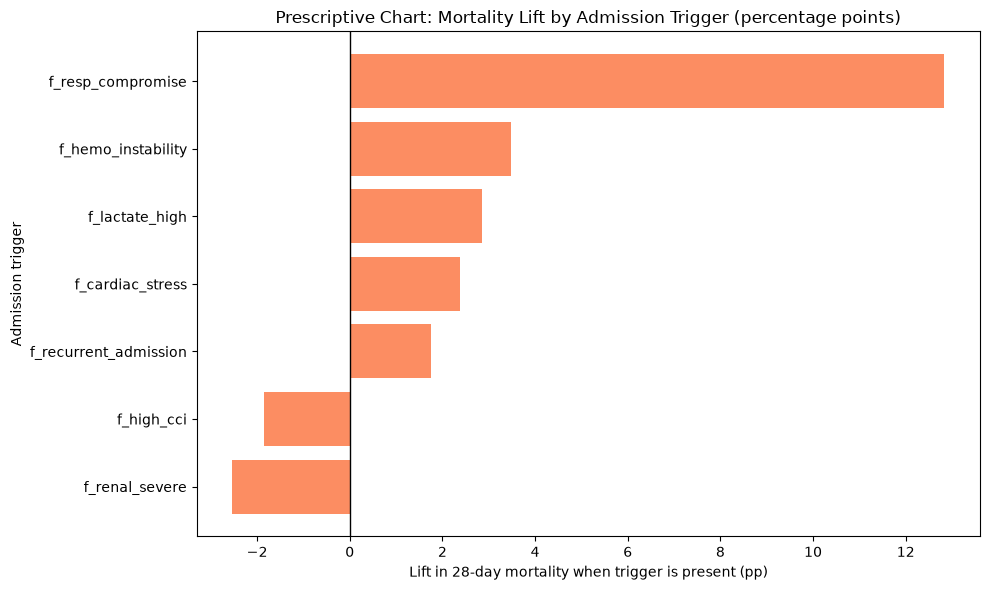

,trigger,mortality_when_present,mortality_when_absent,lift_pp
1,f_resp_compromise,13.846154,1.011715,12.834439
0,f_hemo_instability,5.194805,1.708959,3.485846
2,f_lactate_high,4.072398,1.213282,2.859116
4,f_cardiac_stress,3.823529,1.438849,2.384680
6,f_recurrent_admission,3.571429,1.818182,1.753247
5,f_high_cci,0.000000,1.843548,-1.843548
3,f_renal_severe,1.813602,4.347826,-2.534224
7,f_older_age,NaN,1.842629,NaN


In [12]:
# ...existing code...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load merged data (or reuse df if already in memory)
df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

# ---------- Helpers ----------
def to_binary_outcome(s):
    if s.dtype.kind in "biufc":
        return pd.to_numeric(s, errors="coerce").fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    pos = {"1", "yes", "y", "dead", "death", "deceased", "true"}
    return txt.isin(pos).astype(int)

def col_exists(name):
    return name in df.columns

# Optional validation outcome
if col_exists("mortality_28d"):
    df["mortality_28d_bin"] = to_binary_outcome(df["mortality_28d"])
elif col_exists("death_within_28_days"):
    df["mortality_28d_bin"] = to_binary_outcome(df["death_within_28_days"])
else:
    df["mortality_28d_bin"] = np.nan

# ---------- Numeric casting ----------
num_cols = ["systolic_bp", "diastolic_bp", "pulse", "respiration", "po2", "fio2",
            "lactate", "gfr", "creatinine", "hs_troponin", "bnp", "cci_score", "visit_count"]
for c in num_cols:
    if col_exists(c):
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ---------- Admission-factor triggers ----------
df["f_hemo_instability"] = (
    ((df["systolic_bp"] < 90) if col_exists("systolic_bp") else False) |
    ((df["pulse"] > 130) if col_exists("pulse") else False) |
    ((df["respiration"] > 30) if col_exists("respiration") else False)
).astype(int)

df["f_resp_compromise"] = (
    ((df["po2"] < 60) if col_exists("po2") else False) |
    ((df["fio2"] >= 40) if col_exists("fio2") else False)
).astype(int)

df["f_lactate_high"] = ((df["lactate"] >= 2.0) if col_exists("lactate") else False).astype(int)
df["f_renal_severe"] = (
    ((df["gfr"] < 30) if col_exists("gfr") else False) |
    ((df["creatinine"] >= 2.0) if col_exists("creatinine") else False)
).astype(int)

# Use dataset-relative high thresholds for markers
troponin_q90 = df["hs_troponin"].quantile(0.90) if col_exists("hs_troponin") and df["hs_troponin"].notna().any() else np.nan
bnp_q90 = df["bnp"].quantile(0.90) if col_exists("bnp") and df["bnp"].notna().any() else np.nan

df["f_cardiac_stress"] = (
    ((df["hs_troponin"] >= troponin_q90) if col_exists("hs_troponin") and pd.notna(troponin_q90) else False) |
    ((df["bnp"] >= bnp_q90) if col_exists("bnp") and pd.notna(bnp_q90) else False)
).astype(int)

df["f_high_cci"] = ((df["cci_score"] >= 6) if col_exists("cci_score") else False).astype(int)
df["f_recurrent_admission"] = ((df["visit_count"] >= 3) if col_exists("visit_count") else False).astype(int)

if col_exists("age_category"):
    age_txt = df["age_category"].astype("string").str.lower()
    df["f_older_age"] = age_txt.str.contains("70|75|80|85|90|elder|old", regex=True, na=False).astype(int)
else:
    df["f_older_age"] = 0

trigger_cols = [
    "f_hemo_instability", "f_resp_compromise", "f_lactate_high",
    "f_renal_severe", "f_cardiac_stress", "f_high_cci",
    "f_recurrent_admission", "f_older_age"
]
df["escalation_score"] = df[trigger_cols].sum(axis=1)

# Escalation rule:
# Immediate if any RED FLAG (hemo/resp/lactate) OR total score >= 3
df["icu_escalate_early"] = (
    (df["f_hemo_instability"] == 1) |
    (df["f_resp_compromise"] == 1) |
    (df["f_lactate_high"] == 1) |
    (df["escalation_score"] >= 3)
).astype(int)

# ---------- Summary ----------
summary = pd.DataFrame({
    "metric": ["Total patients", "Escalate early", "Escalation rate (%)"],
    "value": [
        len(df),
        int(df["icu_escalate_early"].sum()),
        round(100 * df["icu_escalate_early"].mean(), 2)
    ]
})
display(summary)

# Trigger prevalence among escalated patients
esc = df[df["icu_escalate_early"] == 1]
trigger_prev = (esc[trigger_cols].mean() * 100).sort_values(ascending=False).round(1)
display(trigger_prev.rename("prevalence_in_escalated_%").to_frame())


# ...existing code...

# Single clear prescriptive chart:
# "Which admission triggers are associated with higher 28-day mortality?"
if df["mortality_28d_bin"].notna().any():
    rows = []
    for t in trigger_cols:
        if t in df.columns:
            present = df.loc[df[t] == 1, "mortality_28d_bin"].mean() * 100
            absent = df.loc[df[t] == 0, "mortality_28d_bin"].mean() * 100
            lift = present - absent
            rows.append([t, present, absent, lift])

    effect = pd.DataFrame(rows, columns=["trigger", "mortality_when_present", "mortality_when_absent", "lift_pp"])
    effect = effect.sort_values("lift_pp", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(effect["trigger"], effect["lift_pp"], color="#fc8d62")
    plt.axvline(0, color="black", linewidth=1)
    plt.title("Prescriptive Chart: Mortality Lift by Admission Trigger (percentage points)")
    plt.xlabel("Lift in 28-day mortality when trigger is present (pp)")
    plt.ylabel("Admission trigger")
    plt.tight_layout()
    plt.show()

    display(effect.sort_values("lift_pp", ascending=False))
else:
    print("28-day mortality column not available for trigger-effect chart.")

# ...existing code...


### ***16. Which patients are most likely to be readmitted within 28 days if discharged early?***
Patients who should receive a formal discharge planning bundle are those with signs of both clinical instability and higher baseline risk in your dataset. 

In simple terms, this includes patients with low systolic BP, poor kidney function (low GFR/high creatinine), high comorbidity burden (high CCI score), frequent prior visits, older age category, and elevated cardiac markers (troponin/BNP). 

These patterns indicate they are more likely to have early complications, readmission, or death after discharge, so they need structured discharge support (medication reconciliation, early follow-up, warning-sign education, and care coordination) before leaving the hospital.

Readmission risk by segment:


/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_3480/946060125.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["discharged_early"] = (
/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_3480/946060125.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["readmit_28d_bin"] = to_bin(df[readmit_col])
/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_3480/946060125.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which 

,segment,rate,n
1,Mild (1),5.000000,60
0,Very Low (0),2.857143,70
2,Moderate (2),0.000000,5
3,High (3-4),0.000000,1


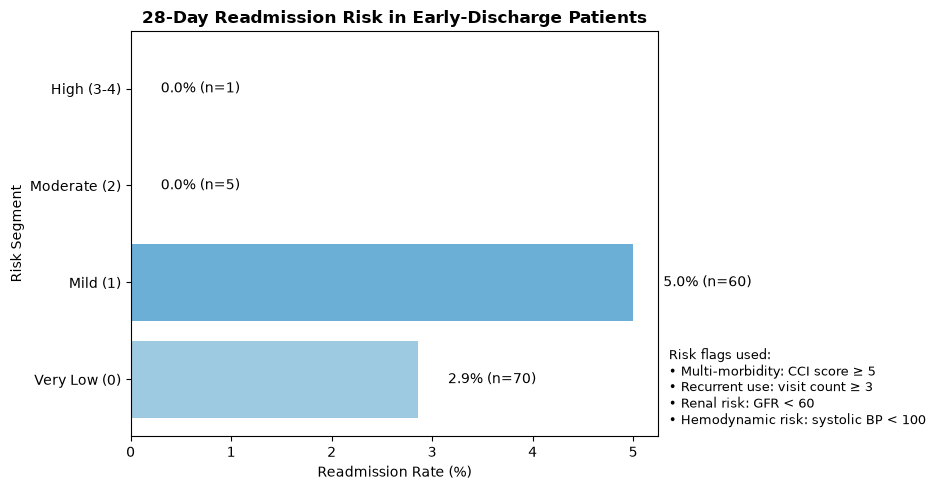

In [10]:
# Resolve column names
if "df" not in globals():
    df = pd.read_csv("cleaned_files/heart_failure_merged.csv")

work = df.copy()
readmit_col = (
    "readmission_28d"
    if "readmission_28d" in df.columns
    else "readmitted_within_28_days"
)

early_col = (
    "early_discharge"
    if "early_discharge" in df.columns
    else "discharged_early"
)

# Derive early discharge if missing
if early_col not in df.columns:
    if "discharge_day" in df.columns:
        df["discharged_early"] = (
            pd.to_numeric(df["discharge_day"], errors="coerce")
            .le(3)
            .astype(int)
        )
        early_col = "discharged_early"
    else:
        raise ValueError(
            "Need early-discharge column or discharge_day to derive it."
        )

# Check readmission column
if readmit_col not in df.columns:
    raise ValueError(
        "Need readmission column "
        "(readmission_28d or readmitted_within_28_days)."
    )


# Convert Yes/No, True/False, 1/0 to binary
def to_bin(s):
    num = pd.to_numeric(s, errors="coerce")

    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)

    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true"]).astype(int)


# Binary outcomes
df["readmit_28d_bin"] = to_bin(df[readmit_col])
df["early_discharge_bin"] = to_bin(df[early_col])


# Keep only early-discharge patients
sub = df[df["early_discharge_bin"] == 1].copy()


# Convert risk variables to numeric
for c in ["cci_score", "visit_count", "gfr", "systolic_bp"]:
    if c in sub.columns:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")


# Create risk flags
sub["risk_multi_morbidity"] = (
    (sub["cci_score"] >= 5).astype(int)
    if "cci_score" in sub.columns else 0
)

sub["risk_recurrent_use"] = (
    (sub["visit_count"] >= 3).astype(int)
    if "visit_count" in sub.columns else 0
)

sub["risk_renal"] = (
    (sub["gfr"] < 60).astype(int)
    if "gfr" in sub.columns else 0
)

sub["risk_hemo"] = (
    (sub["systolic_bp"] < 100).astype(int)
    if "systolic_bp" in sub.columns else 0
)


# Composite risk score
risk_cols = [
    "risk_multi_morbidity",
    "risk_recurrent_use",
    "risk_renal",
    "risk_hemo"
]

sub["risk_score"] = sub[risk_cols].sum(axis=1)


# Create risk segments
segment_order = [
    "Very Low (0)",
    "Mild (1)",
    "Moderate (2)",
    "High (3-4)"
]

sub["segment"] = pd.cut(
    sub["risk_score"],
    bins=[-1, 0, 1, 2, 4],
    labels=segment_order
)


# Calculate readmission rate by segment
seg = (
    sub.groupby("segment", observed=False)["readmit_28d_bin"]
    .agg(rate="mean", n="count")
    .reset_index()
)

seg["rate"] = seg["rate"] * 100

print("Readmission risk by segment:")
display(seg.sort_values("rate", ascending=False))


# Plot
fig, ax = plt.subplots(figsize=(9.5, 5))

ax.barh(
    seg["segment"].astype(str),
    seg["rate"],
    color=["#9ECAE1", "#6BAED6", "#3182BD", "#08519C"]
)

# Add rate and sample size
for i, r in seg.reset_index(drop=True).iterrows():
    ax.text(
        r["rate"] + 0.3,
        i,
        f'{r["rate"]:.1f}% (n={int(r["n"])})',
        va="center"
    )


# Explain risk flags
flags_text = (
    "Risk flags used:\n"
    "• Multi-morbidity: CCI score ≥ 5\n"
    "• Recurrent use: visit count ≥ 3\n"
    "• Renal risk: GFR < 60\n"
    "• Hemodynamic risk: systolic BP < 100"
)

ax.text(
    1.02,
    0.02,
    flags_text,
    transform=ax.transAxes,
    fontsize=9,
    va="bottom"
)

ax.set_title(
    "28-Day Readmission Risk in Early-Discharge Patients",
    fontweight="bold"
)

ax.set_xlabel("Readmission Rate (%)")
ax.set_ylabel("Risk Segment")

plt.tight_layout()
plt.show()

Insights: 

The highest readmission rate occurs in the Mild (1) risk segment, which stands at 5.0% (comprising 60 patients).

The Very Low (0) risk segment has a readmission rate of 2.9%, which makes up the largest patient cohort in this chart (70 patients).

The Moderate (2) and High (3-4) risk segments both show a 0.0% readmission rate. However, their sample sizes are extremely small (\(n=5\) and \(n=1\), respectively), meaning these percentages are not statistically reliable indicators of true risk. 

### ***16. Which patients are most likely to be readmitted within 28 days if discharged early?***
Patients who should receive a formal discharge planning bundle are those with signs of both clinical instability and higher baseline risk in your dataset. In simple terms, this includes patients with low systolic BP, poor kidney function (low GFR/high creatinine), high comorbidity burden (high CCI score), frequent prior visits, older age category, and elevated cardiac markers (troponin/BNP). These patterns indicate they are more likely to have early complications, readmission, or death after discharge, so they need structured discharge support (medication reconciliation, early follow-up, warning-sign education, and care coordination) before leaving the hospital.

Insights: 

Recommended patients face significantly higher risks. 

Patients flagged as "Recommended" for the formal discharge bundle have more than double the Readmission 28d rate (9.8% vs. 4.4%) and more than double the Mortality 28d rate (2.7% vs. 1.1%) compared to those who are Not Recommended.


This wide gap in outcomes validates that the selection algorithm is successfully isolating the highest-risk patient population.

### ***17. Which patients need a home-based follow-up plan instead of routine discharge?***

Patients who need a home-based follow-up plan instead of routine discharge are those with the highest post-discharge risk profile in your dataset: 

low systolic_bp, renal dysfunction (gfr < 60 or high creatinine), high comorbidity burden (cci_score high), frequent prior admissions (visit_count >= 3), older age category, and elevated cardiac markers (hs_troponin/bnp). 

These patients are more likely to deteriorate, be readmitted, or die within 28 days, so routine discharge is usually insufficient. 

A home-based plan is more appropriate because it adds close monitoring, early symptom detection, medication support, and faster escalation if condition worsens

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def to_bin(s: pd.Series) -> pd.Series:
    num = pd.to_numeric(s, errors="coerce")
    if num.notna().any():
        return num.fillna(0).astype(int).clip(0, 1)
    txt = s.astype("string").str.strip().str.lower()
    return txt.isin(["1", "yes", "y", "true", "dead", "death", "deceased"]).astype(int)


def q75(series: pd.Series) -> float:
    return series.quantile(0.75) if series.notna().any() else np.nan


def build_home_followup_prescriptive(df: pd.DataFrame):
    df = df.copy()

    # Optional outcomes
    mort_col = "mortality_28d" if "mortality_28d" in df.columns else ("death_within_28_days" if "death_within_28_days" in df.columns else None)
    readm_col = "readmission_28d" if "readmission_28d" in df.columns else ("readmitted_within_28_days" if "readmitted_within_28_days" in df.columns else None)

    df["mortality_28d_bin"] = to_bin(df[mort_col]) if mort_col else np.nan
    df["readmit_28d_bin"] = to_bin(df[readm_col]) if readm_col else np.nan

    # Numeric casting
    for c in ["systolic_bp", "gfr", "creatinine", "cci_score", "visit_count", "hs_troponin", "bnp"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # Dynamic thresholds
    troponin_q75 = q75(df["hs_troponin"]) if "hs_troponin" in df.columns else np.nan
    bnp_q75 = q75(df["bnp"]) if "bnp" in df.columns else np.nan

    # Risk flags
    df["f_low_sbp"] = ((df["systolic_bp"] < 100) if "systolic_bp" in df.columns else False).astype(int)
    df["f_renal_risk"] = (
        ((df["gfr"] < 60) if "gfr" in df.columns else False) |
        ((df["creatinine"] > 1.5) if "creatinine" in df.columns else False)
    ).astype(int)
    df["f_high_cci"] = ((df["cci_score"] >= 5) if "cci_score" in df.columns else False).astype(int)
    df["f_recurrent_use"] = ((df["visit_count"] >= 3) if "visit_count" in df.columns else False).astype(int)
    df["f_cardiac_stress"] = (
        ((df["hs_troponin"] >= troponin_q75) if "hs_troponin" in df.columns and pd.notna(troponin_q75) else False) |
        ((df["bnp"] >= bnp_q75) if "bnp" in df.columns and pd.notna(bnp_q75) else False)
    ).astype(int)

    if "age_category" in df.columns:
        age_txt = df["age_category"].astype("string").str.lower()
        df["f_older_age"] = age_txt.str.contains("70|75|80|85|90|elder|old", regex=True, na=False).astype(int)
    else:
        df["f_older_age"] = 0

    flag_cols = ["f_low_sbp", "f_renal_risk", "f_high_cci", "f_recurrent_use", "f_cardiac_stress", "f_older_age"]
    df["home_risk_score"] = df[flag_cols].sum(axis=1)

    # Prescriptive recommendation
    df["home_followup_recommended"] = (
        (df["home_risk_score"] >= 3) |
        ((df["f_low_sbp"] == 1) & (df["f_renal_risk"] == 1)) |
        ((df["home_risk_score"] >= 2) & (df["f_older_age"] == 1))
    ).astype(int)

    # Priority tiers
    df["home_priority"] = np.select(
        [
            df["home_risk_score"] >= 4,
            df["home_risk_score"].between(2, 3),
            df["home_risk_score"] <= 1
        ],
        [
            "Priority A: Intensive home follow-up (24-48h call + 7d home/clinic review)",
            "Priority B: Moderate home follow-up (72h call + 14d review)",
            "Priority C: Routine discharge follow-up"
        ],
        default="Priority C: Routine discharge follow-up"
    )

    # Overview table
    overview = (
        df.groupby("home_priority", dropna=False)
          .agg(
              patients=("home_priority", "count"),
              avg_score=("home_risk_score", "mean"),
              readmit_rate_28d=("readmit_28d_bin", "mean"),
              mortality_rate_28d=("mortality_28d_bin", "mean")
          )
          .reset_index()
    )

    for col in ["readmit_rate_28d", "mortality_rate_28d"]:
        if col in overview.columns:
            overview[col] = (overview[col] * 100).round(2)

    priority_order = [
        "Priority A: Intensive home follow-up (24-48h call + 7d home/clinic review)",
        "Priority B: Moderate home follow-up (72h call + 14d review)",
        "Priority C: Routine discharge follow-up"
    ]
    overview["home_priority"] = pd.Categorical(overview["home_priority"], categories=priority_order, ordered=True)
    overview = overview.sort_values("home_priority")

    return df, overview, flag_cols


def plot_home_followup_detailed(df: pd.DataFrame, flag_cols):
    flag_labels = {
        "f_low_sbp": "Low SBP (<100)",
        "f_renal_risk": "Renal risk (GFR<60 / Cr>1.5)",
        "f_high_cci": "High comorbidity (CCI≥5)",
        "f_recurrent_use": "Frequent prior visits (≥3)",
        "f_cardiac_stress": "Cardiac stress (high troponin/BNP)",
        "f_older_age": "Older age category"
    }

    prev = (
        df.groupby("home_followup_recommended")[flag_cols]
          .mean()
          .T
          .reset_index()
          .rename(columns={"index": "flag", 0: "Not Recommended", 1: "Recommended"})
    )
    prev["flag"] = prev["flag"].map(flag_labels)
    prev["Not Recommended"] = prev["Not Recommended"] * 100
    prev["Recommended"] = prev["Recommended"] * 100

    out = df.groupby("home_followup_recommended").agg(
        readmit=("readmit_28d_bin", "mean"),
        mortality=("mortality_28d_bin", "mean"),
        n=("home_followup_recommended", "count")
    ).reset_index()
    out["readmit"] = out["readmit"] * 100
    out["mortality"] = out["mortality"] * 100
    out["group"] = out["home_followup_recommended"].map({0: "Not Recommended", 1: "Recommended"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    y = np.arange(len(prev))
    h = 0.38
    axes[0].barh(y - h / 2, prev["Not Recommended"], height=h, color="#b3cde3", label="Not Recommended")
    axes[0].barh(y + h / 2, prev["Recommended"], height=h, color="#005b96", label="Recommended")
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(prev["flag"])
    axes[0].set_xlabel("Prevalence (%)")
    axes[0].set_title("Risk-Flag Profile")
    axes[0].legend(loc="lower right")

    x = np.arange(len(out))
    w = 0.35
    axes[1].bar(x - w / 2, out["readmit"], width=w, color="#6baed6", label="Readmission 28d")
    axes[1].bar(x + w / 2, out["mortality"], width=w, color="#fb6a4a", label="Mortality 28d")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(out["group"])
    axes[1].set_ylabel("Rate (%)")
    axes[1].set_title("Observed 28-day Outcomes")
    axes[1].legend()

    for i, r in out.iterrows():
        axes[1].text(i - w / 2, r["readmit"] + 0.3, f"{r['readmit']:.1f}%", ha="center", fontsize=9)
        axes[1].text(i + w / 2, r["mortality"] + 0.3, f"{r['mortality']:.1f}%", ha="center", fontsize=9)

    plt.suptitle("Q23 Prescriptive Analysis: Who Needs Home-Based Follow-up Instead of Routine Discharge?", y=1.03)
    plt.tight_layout()
    plt.show()


def run_home_followup_analysis(csv_path="cleaned_files/heart_failure_merged.csv"):
    df = pd.read_csv(csv_path)
    scored_df, overview, flag_cols = build_home_followup_prescriptive(df)
    print("Prescriptive home-follow-up overview:")
    print(overview)
    plot_home_followup_detailed(scored_df, flag_cols)
    rate = 100 * scored_df["home_followup_recommended"].mean()
    print(f"Recommended for home-based follow-up: {rate:.1f}% of patients.")
    return scored_df, overview


   